# 03 - Feature Engineering

## Objective
Build the modeling-ready feature set from weekly sales + weather data.

## Features Created
1. **Seasonality** — Fourier terms (week-of-year, monthly)
2. **Calendar** — holidays, season flags, year index
3. **Weather** — raw values + deviation z-scores + temperature lags + temp shock
4. **Weather × Season interactions** — precip/bad weather/sunshine × summer/spring
5. **Sales lags** — 1w, 2w, 4w, 52w (YoY) + rolling 4w/8w/12w + volatility
6. **Revenue lags** — 1w, 4w + rolling mean + avg price per unit (for future revenue model)

## Input
- `data/processed/weekly_units_weather.csv`

## Output
- `data/processed/modeling_dataset.csv`
---

---
## Cell 1: Imports
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: Load Data
---

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'weekly_units_weather.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])
df = df.sort_values(['store_code','division_code','week_ending']).reset_index(drop=True)

GROUP_COLS = ['store_code','city','division_code']

print(f'Dataset: {df.shape}')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
assert 'units' in df.columns, "Missing 'units' column — check nb01 output"
print(f'Dataset: {df.shape}')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
print(f'Stores: {df["store_code"].nunique()}  Divisions: {df["division_code"].nunique()}')
print(f'Columns: {df.columns.tolist()}')

Dataset: (24323, 24)
Date range: 2023-11-05 → 2026-03-22
Dataset: (24323, 24)
Date range: 2023-11-05 → 2026-03-22
Stores: 27  Divisions: 11
Columns: ['week_ending', 'store_code_x', 'city', 'division_code', 'units', 'revenue', 'n_transactions', 'revenue_clean', 'is_return', 'is_active_product', 'weeks_with_sales', 'store_code_y', 'province', 'avg_temp', 'max_temp', 'total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days', 'store_code', 'n_holidays', 'has_holiday', 'month']


In [3]:
print("Actual columns:")
print(df.columns.tolist())

Actual columns:
['week_ending', 'store_code_x', 'city', 'division_code', 'units', 'revenue', 'n_transactions', 'revenue_clean', 'is_return', 'is_active_product', 'weeks_with_sales', 'store_code_y', 'province', 'avg_temp', 'max_temp', 'total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days', 'store_code', 'n_holidays', 'has_holiday', 'month']


---
## Cell 3: Seasonality Features (Fourier Terms)

Annual Fourier terms based on week-of-year.
With 125 weeks (2.4 years) of data, both first and second harmonics
are well-powered for annual cycle detection.
---

In [4]:
df['week_of_yr'] = df['week_ending'].dt.isocalendar().week.astype(int)
df['month']      = df['week_ending'].dt.month
df['year']       = df['week_ending'].dt.year

# Annual Fourier (period = 52 weeks)
df['sin_week_1'] = np.sin(2 * np.pi * df['week_of_yr'] / 52)
df['cos_week_1'] = np.cos(2 * np.pi * df['week_of_yr'] / 52)
df['sin_week_2'] = np.sin(4 * np.pi * df['week_of_yr'] / 52)
df['cos_week_2'] = np.cos(4 * np.pi * df['week_of_yr'] / 52)

# Monthly Fourier (period = 12 months)
df['sin_month_1'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month_1'] = np.cos(2 * np.pi * df['month'] / 12)

SEASONALITY_FEATURES = ['sin_week_1','cos_week_1','sin_week_2','cos_week_2',
                         'sin_month_1','cos_month_1']
print(f'✅ Seasonality features: {SEASONALITY_FEATURES}')

✅ Seasonality features: ['sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2', 'sin_month_1', 'cos_month_1']


---
## Cell 4: Calendar Features
---

In [5]:
df["year_idx"] = df["year"] - df["year"].min()
df["quarter"] = df["week_ending"].dt.quarter

df["is_summer_peak"] = df["month"].isin([6, 7, 8]).astype(int)
df["is_spring_opening"] = df["month"].isin([4, 5]).astype(int)
df["is_fall_closing"] = df["month"].isin([9, 10]).astype(int)
df["is_winter_off"] = df["month"].isin([11, 12, 1, 2, 3]).astype(int)

if "n_holidays" not in df.columns:
    df["n_holidays"] = 0

if "has_holiday" not in df.columns:
    df["has_holiday"] = (df["n_holidays"] > 0).astype(int)

CALENDAR_FEATURES = [
    "year_idx",
    "quarter",
    "week_of_yr",
    "has_holiday",
    "n_holidays",
    "is_summer_peak",
    "is_spring_opening",
    "is_fall_closing"
]

print("Calendar features ready:")
print(CALENDAR_FEATURES)

Calendar features ready:
['year_idx', 'quarter', 'week_of_yr', 'has_holiday', 'n_holidays', 'is_summer_peak', 'is_spring_opening', 'is_fall_closing']


---
## Cell 5: Weather Feature Engineering

Two approaches:
1. **Raw values** — direct weather readings
2. **Deviation z-scores** — deviation from monthly city norm (orthogonal to Fourier seasonality)

QC stores (Longueuil, Gatineau, St-Constant, Beloeil) have similar climate.
Nepean (ON) is slightly different and is treated separately via the city-level merge.
---

In [6]:
WEATHER_RAW = ['avg_temp','total_precip','sunshine_hours','rain_days','snow_days','bad_weather_days']

for col in WEATHER_RAW:
    if col not in df.columns:
        continue
    monthly_avg       = df.groupby(['city','month'])[col].transform('mean')
    df[f'{col}_dev']  = df[col] - monthly_avg
    dev_std           = df[f'{col}_dev'].std()
    df[f'{col}_dev_z']= df[f'{col}_dev'] / dev_std if dev_std > 0 else 0.0

# Temperature threshold flags (important for pool/spa demand triggers)
df['temp_above_20']       = (df['avg_temp'] > 20).astype(int)  # Pool weather
df['temp_above_25']       = (df['avg_temp'] > 25).astype(int)  # Peak pool demand
df['temp_below_0']        = (df['avg_temp'] < 0).astype(int)   # Winter
df['cooling_degree_days'] = (df['avg_temp'] - 18).clip(lower=0)
df['heating_degree_days'] = (18 - df['avg_temp']).clip(lower=0)

# ── Temperature lags (demand responds to LAST week's weather, not just current) ──
df['avg_temp_lag_1w'] = df.groupby(GROUP_COLS)['avg_temp'].shift(1)
df['avg_temp_lag_2w'] = df.groupby(GROUP_COLS)['avg_temp'].shift(2)

# ── Temperature shock (sudden warming/cooling drives pool purchase impulse) ──────
df['temp_shock'] = (df['avg_temp'] - df['avg_temp_lag_1w']).abs()
# Directional: positive = warming (triggers pool demand), negative = cooling
df['temp_warming'] = (df['avg_temp'] - df['avg_temp_lag_1w']).clip(lower=0)

# ── Weather × Season interactions (moved from NB04 — single source of truth) ─────
# These are among the highest-impact features: bad_wx_x_summer ranked #7 in importance
summer = df['is_summer_peak'].astype(int)
spring = df['is_spring_opening'].astype(int)

df['precip_x_summer']     = df['total_precip'] * summer
df['bad_wx_x_summer']     = df['bad_weather_days'] * summer
df['sunshine_x_summer']   = df['sunshine_hours'] * summer
df['temp_above_25_x_sum'] = df['temp_above_25'] * summer
df['precip_x_spring']     = df['total_precip'] * spring
df['temp_warming_x_spr']  = df['temp_warming'] * spring  # Spring warming drives early purchases

WEATHER_FEATURES = (
    WEATHER_RAW
    + [f'{c}_dev_z' for c in WEATHER_RAW if c in df.columns]
    + ['temp_above_20','temp_above_25','temp_below_0',
       'cooling_degree_days','heating_degree_days']
    + ['avg_temp_lag_1w','avg_temp_lag_2w','temp_shock','temp_warming']
    + ['precip_x_summer','bad_wx_x_summer','sunshine_x_summer',
       'temp_above_25_x_sum','precip_x_spring','temp_warming_x_spr']
)
print(f'✅ Weather features: {len([c for c in WEATHER_FEATURES if c in df.columns])} features')
print(f'   New: temp lags (1w, 2w), temp_shock, temp_warming, 6 interaction terms')

✅ Weather features: 27 features
   New: temp lags (1w, 2w), temp_shock, temp_warming, 6 interaction terms


---
## Cell 6: Sales Lag & Rolling Features

Applied per `store_code × division_code` group to avoid cross-series leakage.

**Features added:**
- Unit lags: 1w, 2w, 4w, **52w (YoY)**
- Rolling windows: 4w, **8w, 12w** (mean + std)
- **Demand volatility** (coefficient of variation)
- **Revenue lags**: 1w, 4w + rolling mean + avg price per unit

**Note:** Prophet does NOT use lag features — it models autocorrelation internally.
These are for XGBoost and similar models.
---

In [7]:
def add_lag_features(group):
    group = group.sort_values('week_ending').copy()

    # ── Unit lags (1w, 2w, 4w + YoY 52w) ─────────────────────────────────────
    for lag in [1, 2, 4]:
        group[f'units_lag_{lag}w'] = group['units'].shift(lag)
    # Year-over-year lag: captures growth trends independent of Fourier seasonality
    # ~73 valid weeks with 125-week history
    group['units_lag_52w'] = group['units'].shift(52)

    # ── Rolling windows: 4w, 8w, 12w (mean + std) ────────────────────────────
    # All shifted by 1 to prevent look-ahead
    shifted = group['units'].shift(1)
    for win in [4, 8, 12]:
        min_p = max(2, win // 2)
        group[f'units_roll{win}_mean'] = shifted.rolling(win, min_periods=min_p).mean()
        group[f'units_roll{win}_std']  = shifted.rolling(win, min_periods=min_p).std()

    # ── Demand volatility (coefficient of variation) ──────────────────────────
    # Scale-invariant; lets XGBoost segment high-variance stores differently
    group['units_volatility'] = (
        group['units_roll4_std'] /
        group['units_roll4_mean'].replace(0, np.nan)
    )

    # ── Revenue lags (for future revenue forecasting) ─────────────────────────
    if 'revenue' in group.columns:
        for lag in [1, 4]:
            group[f'revenue_lag_{lag}w'] = group['revenue'].shift(lag)
        group['revenue_roll4_mean'] = group['revenue'].shift(1).rolling(4, min_periods=2).mean()

        # Average price per unit — reveals product mix (luxury vs commodity)
        group['avg_price_per_unit'] = (
            group['revenue'] /
            group['units'].replace(0, np.nan)
        )
        group['price_lag_1w'] = group['avg_price_per_unit'].shift(1)

    return group

# Apply per group (avoid groupby.apply which loses columns in pandas 2.x+)
_parts = []
for _keys, _grp in df.groupby(GROUP_COLS):
    _parts.append(add_lag_features(_grp))
df = pd.concat(_parts, ignore_index=True)

# Verify group columns survived
for _col in GROUP_COLS:
    assert _col in df.columns, f'BUG: {_col} lost after lag computation!'
print(f'✅ Group columns intact: {[c for c in GROUP_COLS if c in df.columns]}')

LAG_FEATURES = [
    # Unit lags
    'units_lag_1w','units_lag_2w','units_lag_4w','units_lag_52w',
    # Rolling windows (4w, 8w, 12w)
    'units_roll4_mean','units_roll4_std',
    'units_roll8_mean','units_roll8_std',
    'units_roll12_mean','units_roll12_std',
    # Volatility
    'units_volatility',
    # Revenue lags
    'revenue_lag_1w','revenue_lag_4w','revenue_roll4_mean',
    'avg_price_per_unit','price_lag_1w',
]
print(f'✅ Lag features: {len(LAG_FEATURES)} features')
print(f'   Units: 4 lags + 6 rolling + 1 volatility')
print(f'   Revenue: 3 lags + 1 avg price + 1 price lag')
print(f'\nNaN counts (expected at series start):')
print(df[LAG_FEATURES].isna().sum())

✅ Group columns intact: ['store_code', 'city', 'division_code']
✅ Lag features: 16 features
   Units: 4 lags + 6 rolling + 1 volatility
   Revenue: 3 lags + 1 avg price + 1 price lag

NaN counts (expected at series start):
units_lag_1w            298
units_lag_2w            595
units_lag_4w           1183
units_lag_52w         14475
units_roll4_mean        595
units_roll4_std         595
units_roll8_mean       1183
units_roll8_std        1183
units_roll12_mean      1769
units_roll12_std       1769
units_volatility        601
revenue_lag_1w          298
revenue_lag_4w         1183
revenue_roll4_mean      595
avg_price_per_unit      355
price_lag_1w            619
dtype: int64


---
## Cell 7: Feature Correlation with Sales
---

Feature correlations with weekly units (top 25 of 57):
  units_lag_1w                        +0.936  ██████████████████
  units_lag_52w                       +0.915  ██████████████████
  units_lag_2w                        +0.875  █████████████████
  units_roll4_mean                    +0.872  █████████████████
  units_roll8_std                     +0.872  █████████████████
  units_roll4_std                     +0.867  █████████████████
  units_roll12_std                    +0.844  ████████████████
  units_roll8_mean                    +0.780  ███████████████
  units_lag_4w                        +0.733  ██████████████
  units_roll12_mean                   +0.706  ██████████████
  revenue_lag_1w                      +0.387  ███████
  revenue_roll4_mean                  +0.376  ███████
  revenue_lag_4w                      +0.294  █████
  avg_temp                            +0.164  ███
  avg_temp_lag_1w                     +0.143  ██
  rain_days                           +0.141  ██
  su

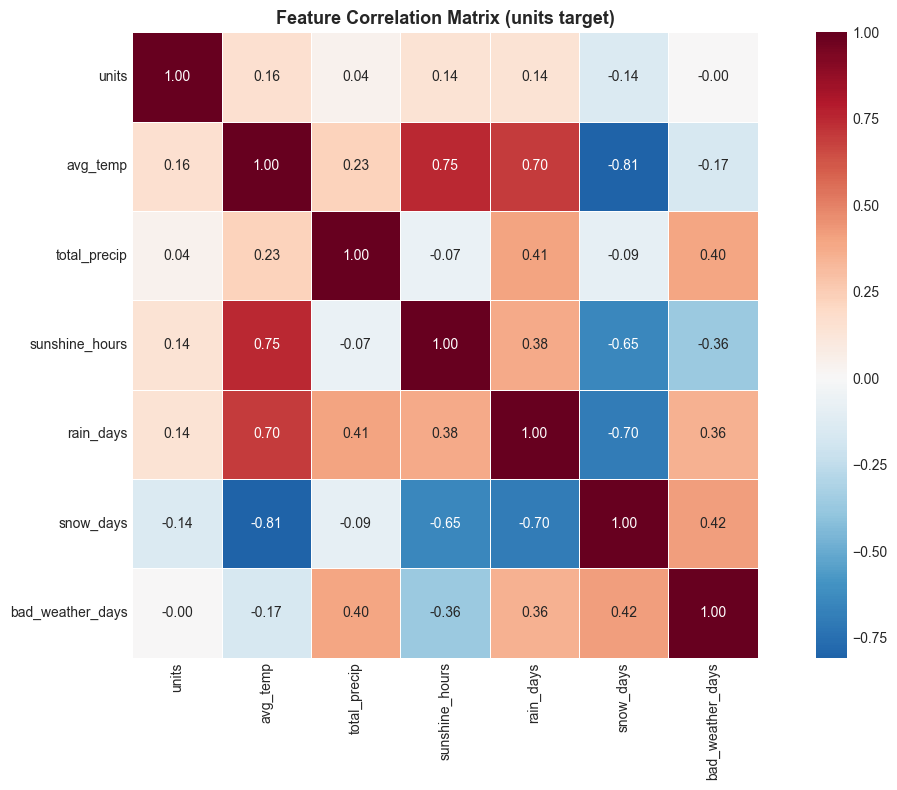

✅ Saved: feature_correlation.png


In [8]:
all_feat = (
    SEASONALITY_FEATURES + CALENDAR_FEATURES
    + [c for c in WEATHER_FEATURES if c in df.columns]
    + [c for c in LAG_FEATURES     if c in df.columns]
)
all_feat = [c for c in all_feat if c in df.columns]

# ── Overall feature correlations with units ───────────────────────────────────
corr = df[['units'] + all_feat].corr()['units'].drop('units').sort_values(ascending=False)

print(f'Feature correlations with weekly units (top 25 of {len(corr)}):')
print('='*55)
for feat, val in corr.head(25).items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:<35} {sign}{abs(val):.3f}  {bar}')

# ── Highlight new features ────────────────────────────────────────────────────
new_feats = ['temp_shock','temp_warming','avg_temp_lag_1w','avg_temp_lag_2w',
             'precip_x_summer','bad_wx_x_summer','sunshine_x_summer',
             'temp_warming_x_spr','units_lag_52w','units_roll8_mean','units_roll12_mean',
             'units_volatility','revenue_lag_1w','avg_price_per_unit','price_lag_1w']
new_feats_present = [f for f in new_feats if f in df.columns]
if new_feats_present:
    print(f'\n── New feature correlations with units ──')
    new_corr = df[['units'] + new_feats_present].corr()['units'].drop('units').sort_values(ascending=False)
    for feat, val in new_corr.items():
        bar  = '█' * int(abs(val) * 20)
        sign = '+' if val >= 0 else '-'
        print(f'  {feat:<35} {sign}{abs(val):.3f}  {bar}')

# ── Heatmap: weather features vs units ───────────────────────────────────────
hm_cols = ['units'] + [c for c in WEATHER_RAW if c in df.columns]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df[hm_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (units target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: feature_correlation.png')

In [9]:
required_lags = ["units_lag_1w", "units_lag_2w", "units_lag_4w"]
df_model = df.dropna(subset=required_lags).copy()

print(f"Full feature dataset : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Model-ready dataset  : {df_model.shape[0]:,} rows × {df_model.shape[1]} cols")
print(f"Dropped {df.shape[0] - df_model.shape[0]:,} rows with missing short-term lags")
print(f"\nFeature groups:")
print(f"  Seasonality : {len(SEASONALITY_FEATURES)}")
print(f"  Calendar    : {len(CALENDAR_FEATURES)}")
print(f"  Weather     : {len([c for c in WEATHER_FEATURES if c in df.columns])}")
print(f"  Lags/Rolling: {len([c for c in LAG_FEATURES if c in df.columns])}")
print(f"  Total engineered: {len(all_feat)}")

Full feature dataset : 24,323 rows × 81 cols
Model-ready dataset  : 23,140 rows × 81 cols
Dropped 1,183 rows with missing short-term lags

Feature groups:
  Seasonality : 6
  Calendar    : 8
  Weather     : 27
  Lags/Rolling: 16
  Total engineered: 57


---
## Cell 8: Save Modeling Dataset
---

In [10]:
df.to_csv(DATA_PROCESSED / 'modeling_dataset.csv', index=False)
print(f'✅ Saved: modeling_dataset.csv  — target: units (Quantité facturée) ({df.shape[0]:,} rows × {df.shape[1]} cols)')

required_lags = ["units_lag_1w", "units_lag_2w", "units_lag_4w"]
df_model = df.dropna(subset=required_lags).copy()
print(f'✅ Model-ready subset: {df_model.shape[0]:,} rows × {df_model.shape[1]} cols')
print(f'\n   New features available for NB04:')
print(f'   - Weather: temp_shock, temp_warming, avg_temp_lag_1w/2w')
print(f'   - Interactions: bad_wx_x_summer, precip_x_summer, sunshine_x_summer, etc.')
print(f'   - Lags: units_lag_52w, units_roll8/12_mean/std, units_volatility')
print(f'   - Revenue: revenue_lag_1w/4w, revenue_roll4_mean, avg_price_per_unit, price_lag_1w')

✅ Saved: modeling_dataset.csv  — target: units (Quantité facturée) (24,323 rows × 81 cols)
✅ Model-ready subset: 23,140 rows × 81 cols

   New features available for NB04:
   - Weather: temp_shock, temp_warming, avg_temp_lag_1w/2w
   - Interactions: bad_wx_x_summer, precip_x_summer, sunshine_x_summer, etc.
   - Lags: units_lag_52w, units_roll8/12_mean/std, units_volatility
   - Revenue: revenue_lag_1w/4w, revenue_roll4_mean, avg_price_per_unit, price_lag_1w
